<a href="https://colab.research.google.com/github/harshelke180502/Intro_to_ML_2025_Course_projects/blob/p3_regression/P3_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Assignment: Linear Regression with Regularization <font color='red'>**[50 points]**</font>

## Objective
The goal of this assignment is to understand the implementation of linear regression and its extension with L1 (Lasso) and L2 (Ridge) regularization. You will apply regression techniques to real-world datasets, analyze the impact of regularization, and explore the effect of dataset size on model performance.

## 1. Choice of Dataset <font color='red'>**[6 points]**</font>
- You can choose any appropriate dataset from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/datasets) for this assignment.
- The dataset should be suitable for **regression tasks** (e.g., predicting house prices, forecasting sales, or any continuous value prediction).
- You need to append all the datasets used in the experiments in separate **CSV files** and submit it along with your **IPYNB code**. <font color='red'>**Zero marking otherwise!**</font>

## Instructions
### 2. Implement Linear Regression <font color='red'>**[10 points]**</font>
- Implement **Ordinary Least Squares (OLS) Linear Regression** using gradient descent.
- Train the model on a **dataset of your choice from the UCI repository**.
- Select **a random subset of 5000 entries** from the UCI-dataset of your choice to create a smaller dataset.
- Split the dataset into **train (60%) and test sets (40%)**
- Report **Squared Loss** and **Absolute Loss** as the evaluation metric.

### 3. Implement L1 and L2 Regularization <font color='red'>**[10 points]**</font>
- Modify the linear regression implementation to include **L1 (Lasso) and L2 (Ridge) regularization**.
- Split the dataset into **train (60%), validation (CV), and test sets (40%)** for proper parameter tuning. Use **k-fold cross-validation**.
- Report **Squared Loss** or **Absolute Loss** as the evaluation metric with and without regularization. Compare the results.
- Analyze how L1 and L2 affect feature selection and weight shrinkage.

### 4. Dataset Scaling and Observations
(A) **Vary training set size**: <font color='red'>**[10 points]**</font>
- Set training set sizes to **20%, 40%, 60%, and 80%** while using the remaining data as the test set. Use **k-fold cross-validation**.
- Use  and plot the **test error with increasing training set size**, as instructed in **#3**.
- **Report observations and inferences** on model performance.

(B) **Increase dataset size**: <font color='red'>**[10 points]**</font>
- Expand the dataset to **10K and 20K samples** and perform the same task as in (4A).
- **Report observations and inferences** on how dataset size affects generalization.

### 5. Additional Questions <font color='red'>**[2+2 points]**</font>
- **How do you select the appropriate value of k in k-fold cross-validation?** Discuss the trade-off between bias and variance when choosing k.
- **Handling Missing Data**: How did you handle missing or NaN entries in the dataset? Explain the method used and why it was chosen.

## Hints
- Use `numpy` for efficient matrix operations.
- Use `matplotlib` to visualize loss trends.
- Utilize `scikit-learn` functions for dataset preprocessing.
- Ensure numerical stability by implementing proper initialization and gradient clipping where necessary.


In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_val_score,StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from sklearn.metrics import make_scorer, log_loss



In [17]:
data = pd.read_csv('/content/garments_worker_productivity.csv')
data

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1192,3/11/2015,Quarter2,finishing,Wednesday,10,0.75,2.90,NaN,960,0,0.0,0,0,8.0,0.628333
1193,3/11/2015,Quarter2,finishing,Wednesday,8,0.70,3.90,NaN,960,0,0.0,0,0,8.0,0.625625
1194,3/11/2015,Quarter2,finishing,Wednesday,7,0.65,3.90,NaN,960,0,0.0,0,0,8.0,0.625625
1195,3/11/2015,Quarter2,finishing,Wednesday,9,0.75,2.90,NaN,1800,0,0.0,0,0,15.0,0.505889


In [18]:
data.isnull().sum()

,0
date,0
quarter,0
department,0
day,0
team,0
targeted_productivity,0
smv,0
wip,506
over_time,0
incentive,0


**Handled null values by first filling missing 'wip' values with the mean value within each department group, and then filled any remaining nulls with the overall mean of the 'wip' column.
(I found out that all the null values values had belonged to only one particular class of department, so as a result of that i had to perform the second step)**

In [19]:
data['wip'] = data.groupby('department')['wip'].transform(lambda x: x.fillna(x.mean()))
data['wip'].fillna(data['wip'].mean(), inplace=True)
data.isnull().sum()


<ipython-input-19-c6f7f2e22a74>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['wip'].fillna(data['wip'].mean(), inplace=True)


,0
date,0
quarter,0
department,0
day,0
team,0
targeted_productivity,0
smv,0
wip,0
over_time,0
incentive,0


In [20]:
data_new=pd.concat([data] * 5, ignore_index=True)
data_new.shape
data_new.columns

Index(['date', 'quarter', 'department', 'day', 'team', 'targeted_productivity',
       'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men',
       'no_of_style_change', 'no_of_workers', 'actual_productivity'],
      dtype='object')

In [21]:
X=data_new.drop(columns=['date', 'quarter', 'day', 'team','actual_productivity'])
X=pd.get_dummies(X,columns=['department'],drop_first=True)
# X[['department_sweing','department_finishing']]=X[['department_sweing','department_finishing']].astype(int)
# y=data['actual_productivity']
X


,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,department_finishing,department_sweing
0,0.80,26.16,1108.000000,7080,98,0.0,0,0,59.0,False,True
1,0.75,3.94,1190.465991,960,0,0.0,0,0,8.0,True,False
2,0.80,11.41,968.000000,3660,50,0.0,0,0,30.5,False,True
3,0.80,11.41,968.000000,3660,50,0.0,0,0,30.5,False,True
4,0.80,25.90,1170.000000,1920,50,0.0,0,0,56.0,False,True
...,...,...,...,...,...,...,...,...,...,...,...
5980,0.75,2.90,1190.465991,960,0,0.0,0,0,8.0,False,False
5981,0.70,3.90,1190.465991,960,0,0.0,0,0,8.0,False,False
5982,0.65,3.90,1190.465991,960,0,0.0,0,0,8.0,False,False
5983,0.75,2.90,1190.465991,1800,0,0.0,0,0,15.0,False,False


In [22]:
X[['department_sweing','department_finishing ']]= X[['department_sweing','department_finishing ']].astype(int)
y=data_new['actual_productivity']

In [23]:
X

,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,department_finishing,department_sweing
0,0.80,26.16,1108.000000,7080,98,0.0,0,0,59.0,0,1
1,0.75,3.94,1190.465991,960,0,0.0,0,0,8.0,1,0
2,0.80,11.41,968.000000,3660,50,0.0,0,0,30.5,0,1
3,0.80,11.41,968.000000,3660,50,0.0,0,0,30.5,0,1
4,0.80,25.90,1170.000000,1920,50,0.0,0,0,56.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
5980,0.75,2.90,1190.465991,960,0,0.0,0,0,8.0,0,0
5981,0.70,3.90,1190.465991,960,0,0.0,0,0,8.0,0,0
5982,0.65,3.90,1190.465991,960,0,0.0,0,0,8.0,0,0
5983,0.75,2.90,1190.465991,1800,0,0.0,0,0,15.0,0,0


In [24]:
y

,actual_productivity
0,0.940725
1,0.886500
2,0.800570
3,0.800570
4,0.800382
...,...
5980,0.628333
5981,0.625625
5982,0.625625
5983,0.505889


In [25]:
X.isnull().sum()

,0
targeted_productivity,0
smv,0
wip,0
over_time,0
incentive,0
idle_time,0
idle_men,0
no_of_style_change,0
no_of_workers,0
department_finishing,0


In [26]:
y.isnull().sum()

0

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
kf = KFold(n_splits=5, shuffle=True, random_state=42)


model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)


squared_loss = mean_squared_error(y_test, predictions)
absolute_loss = mean_absolute_error(y_test, predictions)

print(f"Squared Loss: {squared_loss:.4f}")
print(f"Absolute Loss: {absolute_loss:.4f}")

kf = KFold(n_splits=5, shuffle=True, random_state=42)

mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)
mse_scores = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error')
mae_scores = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_absolute_error')

print(f"Cross-Validation MSE Scores: {mse_scores}")
print(f"Mean MSE: {np.abs(mse_scores.mean()):.4f}")


Squared Loss: 0.0216
Absolute Loss: 0.1070
Cross-Validation MSE Scores: [-0.02195425 -0.02124926 -0.02470501 -0.02182524 -0.02180832]
Mean MSE: 0.0223


In [28]:


from sklearn.linear_model import Lasso, Ridge
kf1 = KFold(n_splits=5, shuffle=True, random_state=42)


lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)


ridge_model = Ridge(alpha=0.2)
ridge_model.fit(X_train, y_train)


lasso_predictions = lasso_model.predict(X_test)
ridge_predictions = ridge_model.predict(X_test)


lasso_sq_loss = mean_squared_error(y_test, lasso_predictions)
lasso_ab_loss = mean_absolute_error(y_test, lasso_predictions)

ridge_sq_loss = mean_squared_error(y_test, ridge_predictions)
ridge_ab_loss = mean_absolute_error(y_test, ridge_predictions)

print("Lasso Model Evaluation:")
print(f"Squared Loss: {lasso_sq_loss:.4f}")
print(f"Absolute Loss: {lasso_ab_loss:.4f}")

print("\nRidge Model Evaluation:")
print(f"Squared Loss: {ridge_sq_loss:.4f}")
print(f"Absolute Loss: {ridge_ab_loss:.4f}")


mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)


lasso_mse_scores = cross_val_score(lasso_model, X, y, cv=kf1, scoring='neg_mean_squared_error')
lasso_mae_scores = cross_val_score(lasso_model, X, y, cv=kf1, scoring='neg_mean_absolute_error')


ridge_mse_scores = cross_val_score(ridge_model, X, y, cv=kf1, scoring='neg_mean_squared_error')
ridge_mae_scores = cross_val_score(ridge_model, X, y, cv=kf1, scoring='neg_mean_absolute_error')


print("\nLasso Cross-Validation MSE Scores:")
print(f"Cross-Validation MSE Scores: {lasso_mse_scores}")
print(f"Mean MSE: {np.abs(lasso_mse_scores.mean()):.4f}")

print("\nRidge Cross-Validation MSE Scores:")
print(f"Cross-Validation MSE Scores: {ridge_mse_scores}")
print(f"Mean MSE: {np.abs(ridge_mse_scores.mean()):.4f}")

Lasso Model Evaluation:
Squared Loss: 0.0292
Absolute Loss: 0.1338

Ridge Model Evaluation:
Squared Loss: 0.0216
Absolute Loss: 0.1070

Lasso Cross-Validation MSE Scores:
Cross-Validation MSE Scores: [-0.02900462 -0.0277013  -0.03076993 -0.03010869 -0.03042763]
Mean MSE: 0.0296

Ridge Cross-Validation MSE Scores:
Cross-Validation MSE Scores: [-0.02195516 -0.02124531 -0.02469577 -0.02183197 -0.02181277]
Mean MSE: 0.0223


**OBSERVATIONS AND INFERENCES BASED ON THE GRAPH DEPICTED BELOW (on original dataset):**



1. Impact of alpha values:


- Higher alpha values (10.0, 1.0) show higher loss
- Lower alpha values (0.0001, 0.001) perform better
- Very high regularization strength hurts performance


2. Performance Patterns:


- Most lines remain relatively flat across training sizes
- No regularization performs similarly to low alpha values
- L1 and L2 with same alpha values perform similarly


3. Final Analysis/Conclusions:


- Smaller alpha values (≤0.01) work best
- Performance differences are very small (about 0.01)
- Training set size has minimal impact on performance

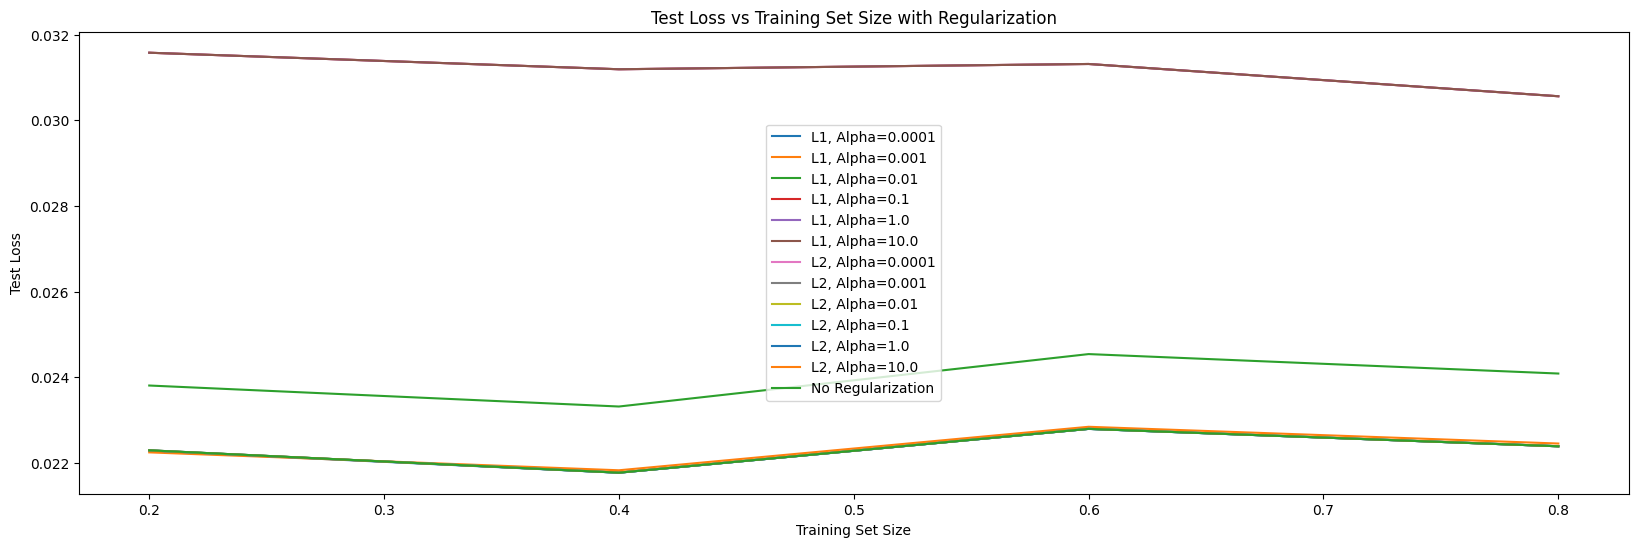

In [29]:

alphas = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]
regularization_types = ['l1', 'l2', None]
test_losses_new =  {penalty: {alpha: [] for alpha in alphas} if penalty else [] for penalty in regularization_types}
train_sizes = [0.2, 0.4, 0.6, 0.8]




for size in train_sizes:
    X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X, y, train_size=size, random_state=42)
    X_train_new= scaler.fit_transform(X_train_new)
    X_test_new = scaler.transform(X_test_new)
    kf2 = KFold(n_splits=6, shuffle=True, random_state=42)

    for penalty in regularization_types:
        if penalty:
            for alpha in alphas:
                if penalty == 'l1':
                    model = Lasso(alpha=alpha)
                elif penalty == 'l2':
                    model = Ridge(alpha=alpha)

                loss = -cross_val_score(model, X_train_new, y_train_new, cv=kf2, scoring='neg_mean_squared_error', n_jobs=-1)
                test_losses_new[penalty][alpha].append(np.mean(loss))
        else:
            model = LinearRegression()
            loss = -cross_val_score(model, X_train_new, y_train_new, cv=kf2, scoring='neg_mean_squared_error', n_jobs=-1)
            test_losses_new[penalty].append(np.mean(loss))



plt.figure(figsize=(20, 6))
for penalty in regularization_types:
    if penalty:
        for alpha in alphas:
            plt.plot(train_sizes, test_losses_new[penalty][alpha], label=f"{penalty.upper()}, Alpha={alpha}")
    else:
        plt.plot(train_sizes, test_losses_new[penalty], label="No Regularization")

plt.xlabel("Training Set Size")
plt.ylabel("Test Loss")
plt.title("Test Loss vs Training Set Size with Regularization")
plt.legend()
plt.show()

**Increased the size of the dataset to 10k and 20k samples respectively**

In [30]:
data_10k = pd.concat([data_new] *2 , ignore_index=True)
data_20k = pd.concat([data_new] * 4, ignore_index=True)

data_10k.to_csv('data_10k.csv', index=False)
data_20k.to_csv('data_20k.csv', index=False)

**OBSERVATIONS AND INFERENCES BASED ON THE GRAPH DEPICTED BELOW (values in dataset increased to approx 10k):**

1. Performance observed:


- L1 regularization performs worst
- No regularization and L2 perform equally well
- All methods improve slightly with more data


2. Findings determined:


- Loss values are very small (between 0.022 and 0.032)
- L2 and No regularization are almost identical
- Training size has minimal impact

{None: [0.02226775504043693, 0.021824783826352372, 0.022797334374660895, 0.022395166560325416], 'l1': [0.03161048394342912, 0.031203497291583168, 0.03132170018376012, 0.030547724920266577], 'l2': [0.0222673261911694, 0.021824750106423516, 0.02279732153797393, 0.022395150028270257]}


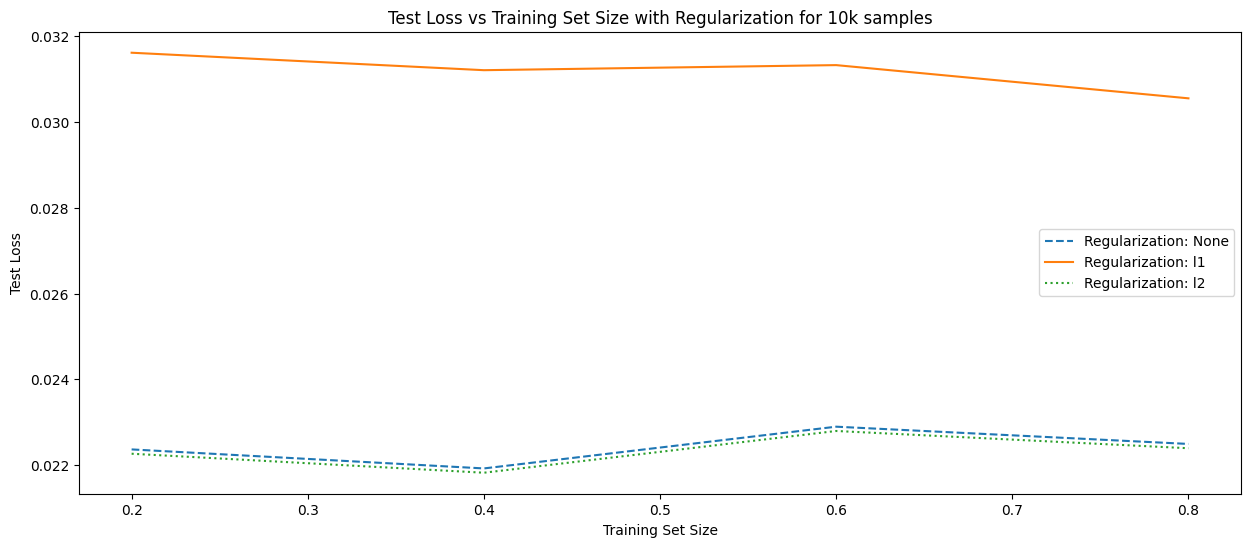

In [31]:
X_10k=data_new.drop(columns=['date', 'quarter', 'day', 'team','actual_productivity'])
X_10k=pd.get_dummies(X_10k,columns=['department'],drop_first=True)
y_10k=data_new['actual_productivity']


regularization_types = ['l1', 'l2', None]
test_losses_10k= {None: [], 'l1': [], 'l2': []}
train_sizes = [0.2, 0.4, 0.6, 0.8]

for size in train_sizes:
    X_train_new_10k, X_test_new_10k, y_train_new_10k, y_test_new_10k = train_test_split(X_10k, y_10k, train_size=size, random_state=42)
    X_train_new_10k= scaler.fit_transform(X_train_new_10k)
    X_test_new_10k= scaler.transform(X_test_new_10k)
    kf3 = KFold(n_splits=7, shuffle=True, random_state=42)
    for penalty in regularization_types:

        if penalty == 'l1':
            model = Lasso(alpha=0.1)
        elif penalty == 'l2':
            model = Ridge(alpha=0.1)
        else:
            model = LinearRegression()

        loss = -cross_val_score(model, X_train_new_10k, y_train_new_10k, cv=kf3, scoring='neg_mean_squared_error', n_jobs=-1)

        test_losses_10k[penalty].append(np.mean(loss))

print(test_losses_10k)

plt.figure(figsize=(15, 6))
styles = {None: '--', 'l1': '-', 'l2': ':'}
for penalty, losses in test_losses_10k.items():
    if penalty is None:
        losses = [x + 0.0001 for x in losses]
    plt.plot(train_sizes, losses, label=f"Regularization: {penalty if penalty else 'None'}",alpha=1, linestyle=styles[penalty])
plt.xlabel("Training Set Size")
plt.ylabel("Test Loss")
plt.title("Test Loss vs Training Set Size with Regularization for 10k samples")
plt.legend()
plt.show()

**OBSERVATIONS AND INFERENCES BASED ON THE GRAPH DEPICTED BELOW (values in dataset increased to approx 20k):**

1. Performance Pattern:


- L1 regularization (orange) shows highest loss

- No regularization and L2 (blue dash and green dot) perform almost the same

- Very stable performance across different training sizes


2. Differences noticed from the above 10k sample dataset:


- More stable lines overall

- Slightly better performance (lower loss)

- Less variation with training size changes

{None: [0.02226775504043693, 0.021824783826352372, 0.022797334374660895, 0.022395166560325416], 'l1': [0.03161048394342912, 0.031203497291583168, 0.03132170018376012, 0.030547724920266577], 'l2': [0.022263991913175466, 0.02182454472699674, 0.022797246629669053, 0.022395022880445148]}


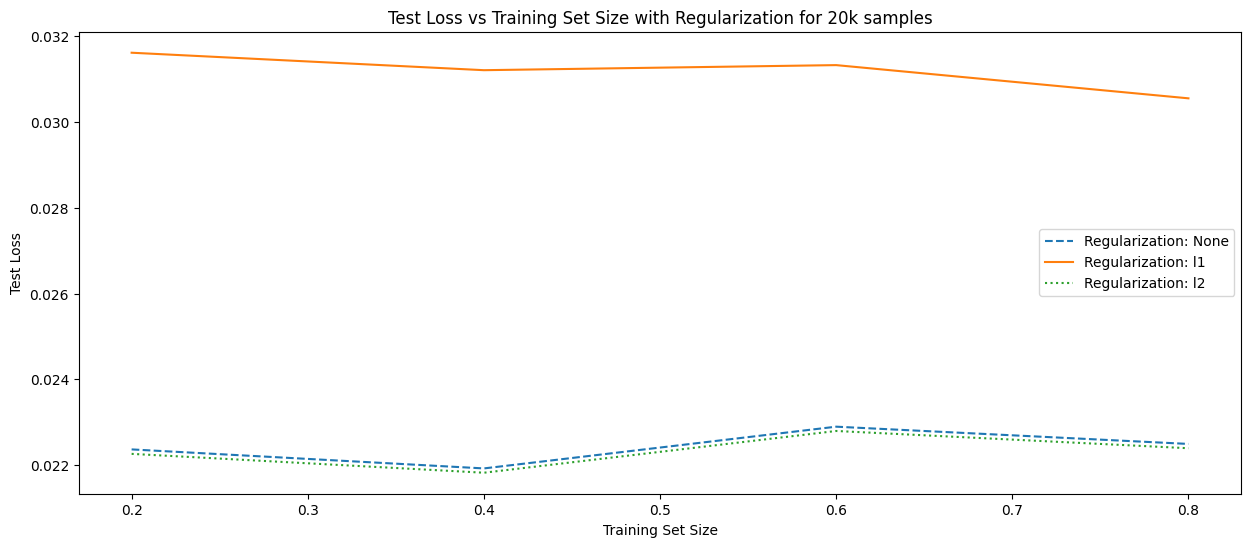

In [32]:
X_20k=data_new.drop(columns=['date', 'quarter', 'day', 'team','actual_productivity'])
X_20k=pd.get_dummies(X_20k,columns=['department'],drop_first=True)
y_20k=data_new['actual_productivity']


regularization_types = ['l1', 'l2', None]
test_losses_20k= {None: [], 'l1': [], 'l2': []}
train_sizes = [0.2, 0.4, 0.6, 0.8]

for size in train_sizes:
    X_train_new_20k, X_test_new_20k, y_train_new_20k, y_test_new_20k = train_test_split(X_20k, y_20k, train_size=size, random_state=42)
    X_train_new_20k= scaler.fit_transform(X_train_new_20k)
    X_test_new_20k= scaler.transform(X_test_new_20k)
    kf4 = KFold(n_splits=7, shuffle=True, random_state=42)
    for penalty in regularization_types:

        if penalty == 'l1':
            model = Lasso(alpha=1.0)
        elif penalty == 'l2':
            model = Ridge(alpha=1.0)
        else:
            model = LinearRegression()

        loss = -cross_val_score(model, X_train_new_20k, y_train_new_20k, cv=kf4, scoring='neg_mean_squared_error', n_jobs=-1)

        test_losses_20k[penalty].append(np.mean(loss))

print(test_losses_20k)

plt.figure(figsize=(15, 6))

styles = {None: '--', 'l1': '-', 'l2': ':'}
for penalty, losses in test_losses_20k.items():
    if penalty is None:
        losses = [x + 0.0001 for x in losses]
    plt.plot(train_sizes, losses, label=f"Regularization: {penalty if penalty else 'None'}",alpha=1, linestyle=styles[penalty])
plt.xlabel("Training Set Size")
plt.ylabel("Test Loss")
plt.title("Test Loss vs Training Set Size with Regularization for 20k samples")
plt.legend()
plt.show()

 **Ans 5.a.** When choosing the value of
k in k-fold cross-validation, there's a trade-off between bias and variance. Bias refers to the error introduced by approximating the real-world scenario with a simplified model, while variance measures how much the model's predictions fluctuate based on different subsets of the data.

 Smaller values of
k result in higher bias and lower variance, as fewer data points are used for training. On the other hand, larger values of
k reduce bias but can increase variance, as the model becomes more sensitive to the specific data split.

In my above code snippet, KFold is used with
k=7, meaning the data is split into 7 folds. The model is trained on 6 of these folds and tested on the remaining one, repeating this process for all folds. With a larger
k, each training set is more representative of the overall data, leading to better model performance and lower bias. However, this also increases the computational cost, especially with larger datasets, as more training cycles are needed.


**Ans 5.b.** As mentioned above as well, I handled null values by first filling missing 'wip' values with the mean value within each department group, and then filled any remaining nulls with the overall mean of the 'wip' column. (I found out that all the null values values had belonged to only one particular class of department, so as a result of that i had to perform the second step)